In [3]:
%matplotlib widget
import warnings
from tqdm import TqdmExperimentalWarning
warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)

import matplotlib.pyplot as plt
import os
import torch
os.environ['TORCH_CUDA_ARCH_LIST'] = f'{torch.cuda.get_device_properties(0).major}.{torch.cuda.get_device_properties(0).minor}'

import torch
from gencase import *
from util import visualize, sampleParticles, generateInitialVariables, SamplingScheme
from sample import smoothState, addNoise, populateCGrid, populateUGrid, smoothValues
from util import plotState, plotInitialState
from simulation import runSimulation
from util import getCurrentTimestamp
from argparse import ArgumentParser

parser = ArgumentParser()

parser.add_argument('--nx', type=int, default=128, help='Number of grid points in one dimension')
parser.add_argument('--sampling', type=str, default='regular', help='Particle sampling scheme: regular, regular_jittered, glass, optimal, random')

parser.add_argument('--dt', type=float, default=0.0025, help='Time step size')
parser.add_argument('--nIter', type=int, default=1024, help='Number of iterations')

parser.add_argument('--uMagnitudes', type=float, nargs='*', default=[10], help='List of possible wave speeds for obstacles')
parser.add_argument('--uRandomMagnitude', action='store_true', help='Enable random magnitudes for sources')
parser.add_argument('--uRandomMin', type=float, default=-10.0, help='Minimum magnitude for sources when uRandomMagnitude is enabled')
parser.add_argument('--uRandomMax', type=float, default=10.0, help='Maximum magnitude for sources when uRandomMagnitude is enabled')

parser.add_argument('--smoothICs', action='store_true', help='Enable smoothing of initial conditions')
parser.add_argument('--smoothIters', type=int, default=4, help='Number of smoothing iterations for initial conditions')

parser.add_argument('--plotInterval', type=int, default=10, help='Plotting interval')
parser.add_argument('--export', action='store_true', help='Whether to export simulation data')
parser.add_argument('--exportImages', action='store_true', help='Whether to export simulation images')

parser.add_argument('--filePrefix', type=str, default='waveEqn', help='Prefix for output files')
parser.add_argument('--verbose', action='store_true', help='Enable verbose output')

parser.add_argument('--domainBox', action='store_true', help='Enable domain boundary box')
parser.add_argument('--domainDamping', action='store_true', help='Enable domain boundary damping')

parser.add_argument('--enableNoise', action='store_true', help='Enable noise addition to initial conditions')
parser.add_argument('--noiseType', type=str, default='perlin', help='Type of noise to add: perlin, uniform, normal')
parser.add_argument('--noiseAmplitude', type=float, default=0.02, help='Amplitude of noise to add to initial conditions')
parser.add_argument('--noiseSmoothIter', type=int, default=4, help='Number of smoothing iterations for noise')
parser.add_argument('--noiseSeed', type=int, default=42, help='Random seed for noise generation')

parser.add_argument('--boundarySpeed', type=float, default=0.01, help='Wave speed at boundaries')
parser.add_argument('--obstacleSpeeds', type=float, nargs='*', default=[0.5], help='List of possible wave speeds for obstacles')


parser.add_argument('--defaultSpeed', type=float, default=1.0, help='Default wave speed in the medium')
parser.add_argument('--randomObstacleSpeed', action='store_true', help='Enable random wave speeds for obstacles')
parser.add_argument('--obstacleSpeedMin', type=float, default=0.3, help='Minimum wave speed for obstacles when randomObstacleSpeed is enabled')
parser.add_argument('--obstacleSpeedMax', type=float, default=0.7, help='Maximum wave speed for obstacles when randomObstacleSpeed is enabled')

parser.add_argument('--figureDpi', type=int, default=200, help='DPI for saved figures')

import shlex
cmdArgs = '--verbose'
splitArgs = shlex.split(cmdArgs)

args = parser.parse_args(splitArgs)

In [4]:

verbose = args.verbose
if verbose:
    print("Simulation Configuration:")
    for arg, value in vars(args).items():
        print(f'{arg}: {value}')

# exit()

device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
if verbose:
    print(f'Using device: {device}')

plotInterval = args.plotInterval
nIter = args.nIter
dt = args.dt
nx = args.nx
# uMagnitude = args.uMagnitude
sampling = args.sampling
samplingScheme = None
export = args.export
timestamp = getCurrentTimestamp()


for scheme in SamplingScheme:
    if scheme.name == sampling:
        samplingScheme = scheme
        if verbose:
            print(f'Using sampling scheme: {samplingScheme.name}')
        break
if samplingScheme is None:
    raise ValueError(f'Unknown sampling scheme: {sampling}')

prefix = f'{args.filePrefix}_{nx}_{sampling}'
os.makedirs('output', exist_ok=True)
folderName = f'{prefix}_{timestamp}'
os.makedirs(f'output/{folderName}', exist_ok=True)
if verbose:
    print(f'Output folder: output/{folderName}')

config, domain, device, dtype, kernel = generateInitialVariables(
    nx, device = device
)
config['integrationScheme'] = IntegrationSchemeType.rungeKutta4
integrator = getIntegrator(config['integrationScheme'])
if verbose:
    print(f'Using integrator: {config["integrationScheme"].name}')


Simulation Configuration:
nx: 128
sampling: regular
dt: 0.0025
nIter: 1024
uMagnitudes: [10]
uRandomMagnitude: False
uRandomMin: -10.0
uRandomMax: 10.0
smoothICs: False
smoothIters: 4
plotInterval: 10
export: False
exportImages: False
filePrefix: waveEqn
verbose: True
domainBox: False
domainDamping: False
enableNoise: False
noiseType: perlin
noiseAmplitude: 0.02
noiseSmoothIter: 4
noiseSeed: 42
boundarySpeed: 0.01
obstacleSpeeds: [0.5]
defaultSpeed: 1.0
randomObstacleSpeed: False
obstacleSpeedMin: 0.3
obstacleSpeedMax: 0.7
figureDpi: 200
Using device: cuda:0
Using sampling scheme: regular
Output folder: output/waveEqn_128_regular_2026-02-04_14-38-46


0it [00:00, ?it/s]

Using integrator: rungeKutta4


In [ ]:
################################################################################
#                             Particle Generation                              #
################################################################################

particles, numNeighbors, counter = sampleParticles(nx, scheme=samplingScheme)
particleState = BasicState(particles.positions, particles.supports, particles.masses, particles.densities, torch.zeros_like(particles.positions), torch.zeros(particles.positions.shape[0], device = device, dtype = torch.int64), torch.zeros(particles.positions.shape[0], device = device, dtype = torch.int64), torch.arange(particles.positions.shape[0], device = device), particles.positions.shape[0])
neighborhood, neighbors = evaluateNeighborhood(particleState, config['domain'], kernel, verletScale = config['neighborhood']['verletScale'], mode = SupportScheme.SuperSymmetric, priorNeighborhood=None)
particleState.numNeighbors = coo_to_csr(filterNeighborhoodByKind(particleState, neighbors.neighbors, which = 'noghost')).rowEntries
particleState.densities = computeDensity(particleState, kernel, neighbors.get('noghost'), SupportScheme.Gather, config)

0it [00:00, ?it/s]

In [ ]:
################################################################################
#                                Boundary Setup                                #
################################################################################

uGrid, vGrid, cGrid, dampGrid, uSourceGrid, cSourceGrid = genInitial(
    particleState, config,
    nx,
    domainBox = args.domainBox,
    domainDamping = args.domainDamping,
)

In [7]:
################################################################################
#                                Source Setup                                  #
################################################################################

if verbose:
    print("Setting up sources...")

sourceCounter = 0
# uSourceGrid, sourceCounter = setupQuadrantSources(particleState, config, nx, uSourceGrid = uSourceGrid, sourceCounter = sourceCounter, radius = 0.15, topLeft = True, topRight = True, bottomLeft = True, bottomRight = True, sourceShape = 'box')
# uSourceGrid, sourceCounter = setupCrossSources(particleState, config, nx, uSourceGrid = uSourceGrid, sourceCounter = sourceCounter, radius = 0.15, sourceTop = False, sourceBottom = False, sourceLeft = True, sourceRight = True, sourceShape = 'circle')
uSourceGrid, sourceCounter = setupCenterSource(particleState, config, nx, uSourceGrid = uSourceGrid, sourceCounter = sourceCounter, radius = 0.15, sourceShape = 'circle')

# for i in range(4):
#     uSourceGrid, sourceCounter = addRandomCircle(particleState, config, nx, uSourceGrid = uSourceGrid, sourceCounter = sourceCounter, radiusRange = (0.05, 0.15), magnitude = 1.0)

Setting up sources...


In [8]:
################################################################################
#                              Obstacle Setup                                  #
################################################################################

if verbose:
    print("Setting up obstacles...")

# cSourceGrid = setupSingleSlit(particleState, config , nx, cSourceGrid, slotWidth = 0.05, slotHeight = 0.2)
# cSourceGrid = setupDoubleSlit(particleState, config, nx, cSourceGrid, slotWidths = [0.05, 0.05], slotHeights = [0.2, -0.2])
# cSourceGrid = setupPrism(particleState, config, nx, cSourceGrid, prismSideLength = 0.5, prismOffset = (0.0, 0.0), prismPreRotation = np.pi/2, prismPostRotation = np.pi/6)
# cSourceGrid = setupRectangle(particleState, config, nx, cSourceGrid, halfExtents = (0.2, 0.1), offset = (0.0, 0.0), preRotation = np.pi/6, postRotation = np.pi/6)
# cSourceGrid = setupSphere(particleState, config, nx, cSourceGrid, radius = 0.2, offset = (0.0, 0.0))

Setting up obstacles...


In [9]:
################################################################################
#                           Initial Condition Setup                            #
################################################################################

if verbose:
    print("Setting up initial conditions...")

uGrid = torch.zeros_like(uGrid)
vGrid = torch.zeros_like(vGrid)

uGrid = populateUGrid(uGrid, uSourceGrid,
    sourceMagnitudes = args.uMagnitudes,
    randomMagnitude = args.uRandomMagnitude,
    magnitudeRange = (args.uRandomMin, args.uRandomMax)
)

if args.smoothICs:
    if verbose:
        print("Smoothing initial conditions...")
    uGrid = smoothValues(
        uGrid,
        particleState,
        args.smoothIters, neighbors,
        config
    )

cGrid = populateCGrid(cGrid, cSourceGrid,
    boundaryC = args.boundarySpeed,
    obstacleC = args.obstacleSpeeds[0],
    defaultC = args.defaultSpeed,
    randomObstacleC = args.randomObstacleSpeed,
    obstacleCRange = (args.obstacleSpeedMin, args.obstacleSpeedMax)
)

uGrid = addNoise(
    particleState, config, neighbors,
    uGrid,
    noiseAmplitude = args.noiseAmplitude, uMagnitude = max(args.uMagnitudes),
    noiseType = args.noiseType,
    smoothIter = args.noiseSmoothIter,
    seed = args.noiseSeed,
)

waveState = WaveEquationState(
    u = uGrid,
    v = vGrid,
    c = cGrid,
    damping = dampGrid,
)
smoothedState = smoothState(waveState, particleState, 0, neighbors, config)

waveSystem = WaveSystem(
    systemState = particleState,
    waveState = smoothedState,
    neighborhood = neighbors.get('noghost'),
    t = 0.0
)

Setting up initial conditions...


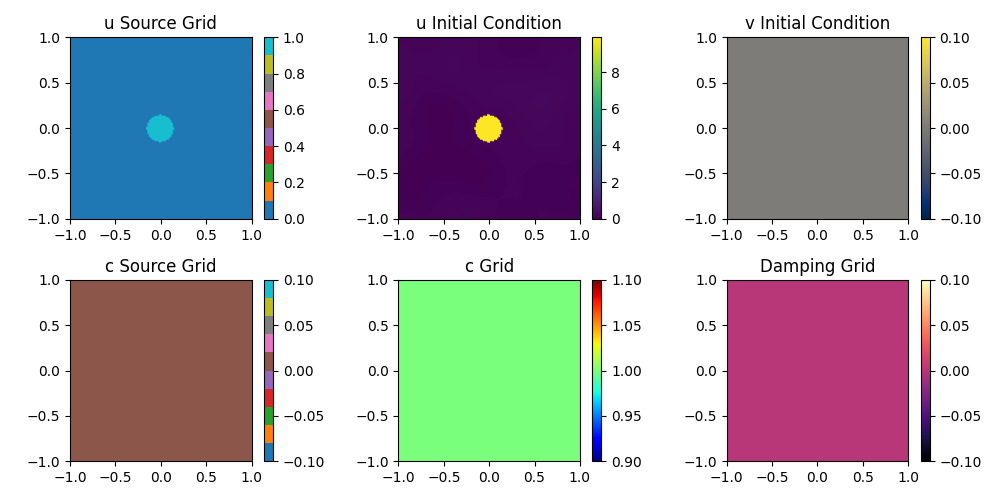

In [ ]:
################################################################################
#                              Visualization Setup                             #
################################################################################

# fig, axis = visualize(particles, numNeighbors, counter)
# fig.savefig(f'output/{folderName}/initial_particles.png', dpi = args.figureDpi)

fig, axis = plotInitialState(
    particleState, config,
    uGrid, vGrid, cGrid, dampGrid,
    uSourceGrid, cSourceGrid
)
fig.savefig(f'output/{folderName}/initial_fields.png', dpi = args.figureDpi)

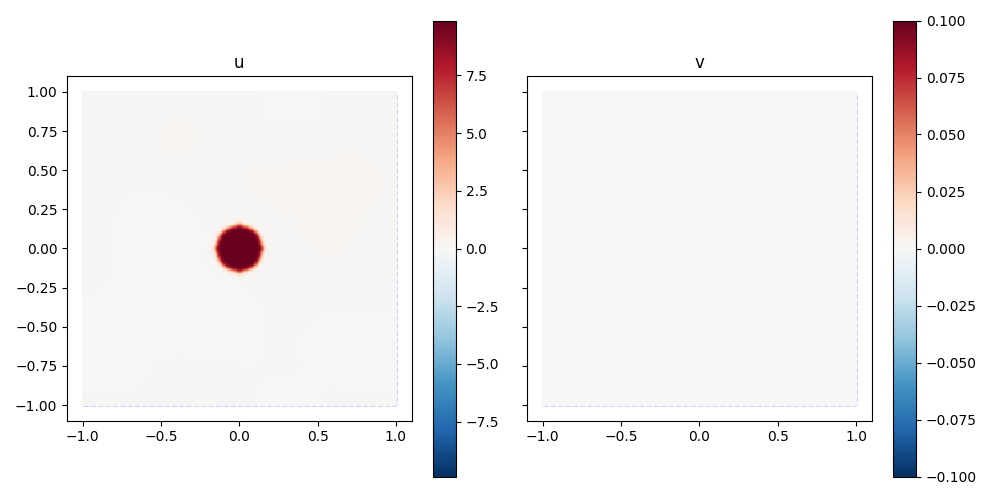

In [12]:

fig, axis, uPlot, vPlot, cPlot, dampPlot = plotState(
    particleState,
    smoothedState,
    config, kernel,
    markerSize = 0.5,
    plotGrid = True,
    plotCD = False)
fig.savefig(f'output/{folderName}/initial_state.png', dpi = args.figureDpi)

In [13]:
################################################################################
#                                Run Simulation                                #
################################################################################

if verbose:
    print("Starting simulation...")

runSimulation(fig, particleState, uPlot, vPlot, waveSystem, waveSystemFunction, integrator, nx, dt, nIter, kernel, config, export, plotInterval = plotInterval, exportImages = args.exportImages, umin = -5, umax = 5, vmin = -50, vmax = 50, prefix = prefix, timestamp = timestamp)

if verbose:
    print("Simulation complete.")

Starting simulation...


  0%|          | 0/1024 [00:00<?, ?it/s]

Simulation complete.
